# Phase 5: Expirementation with Kronecker Sequences

First we import

In [16]:
import math
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import time
import subprocess
import sympy as sp
from sympy.polys.matrices import DomainMatrix
from math_help import rho_3d_lyness_corrected, generate_optimized_g_vectors_3d

Lets state our finds from last time in 3D.

From our findings we found that a better bound (roughly equal to median $\rho$ for N)
is:

$$c * N / (log N)^2$$
With an RMSE ≈ 0.38 
We then found that c = 0.756 worked bessed for our 6 N values, giving us:

$$\rho_{\text{median}}(N) \approx \frac{0.756 \cdot N}{(\log N)^2}$$

<br><br>

We also found that worst case was always $\rho$ = 1, lets  validate that the very short vector gives 1 as a solution.

We will do N = 101. 

In [9]:
# Function that finds the minimum rho for given N value
def find_min_rho_3d(N):
    best_rho = N
    best_g = None
    best_h = None

    for g_vector, weight in generate_optimized_g_vectors_3d(N):
        alpha = (g_vector[1] / N, g_vector[2] / N)
        rho, h = rho_3d_lyness_corrected(N, alpha)

        if rho < best_rho:
            best_rho = rho
            best_g = g_vector
            best_h = h

    print(f"N={N}: min rho = {best_rho}, g = {best_g}, h = {best_h}")
    #return best_rho, best_g

In [10]:
find_min_rho_3d(101)

N=101: min rho = 1.0, g = (1, 1, 1), h = (-1, 0, 1)


We can see that $(\mathbf{h} \cdot \mathbf{g}) \pmod{101}$ = 0 thus the solution is verified
<br><br>

Next we will move on to looking at 4D and 5D and implementing better computation methods to get a better sense of the distribution of $\rho$ values for larger N values
<br><br><br>
### 4 Dimension

First lets look at 4D, the old lyness computation was slow I created a new faster algorithm with the following improvements:

- **Machine Code Translation**: The new code uses a tool called Numba to translate the Python script into super-fast machine code before it runs.

- **Whole Number Math**: It switches from using slow decimal numbers to much faster whole numbers for all calculations.

- **Instant Perfect Score Check**: It quickly checks if the absolute best score (which is 1) is possible right at the start and stops the search immediately if it finds it.

- **Smart Start Bounds**: It tests a few simple, easy-to-calculate points first to drastically shrink the size of the search area before starting the heavy lifting.

- **Running Totals**: It keeps track of running math totals inside the loops to instantly skip millions of bad combinations.

- **Dynamic Loop Limits**: It constantly shrinks the maximum range of the loops as it finds better scores so it never does unnecessary work.

- **Multi-Core Processing**: It splits the massive workload across all of the computer's CPU cores at the same time instead of relying on just one.

- **Safe Data Saving**: It saves the final results directly to a compressed file on the machine.

The code is saved + documented in [fast_comp.py](./fast_comp.py)

<br><br><br>
I ran simultaions for N = [401, 503, 1009, 1511, 2003] the distribution histograms are below:

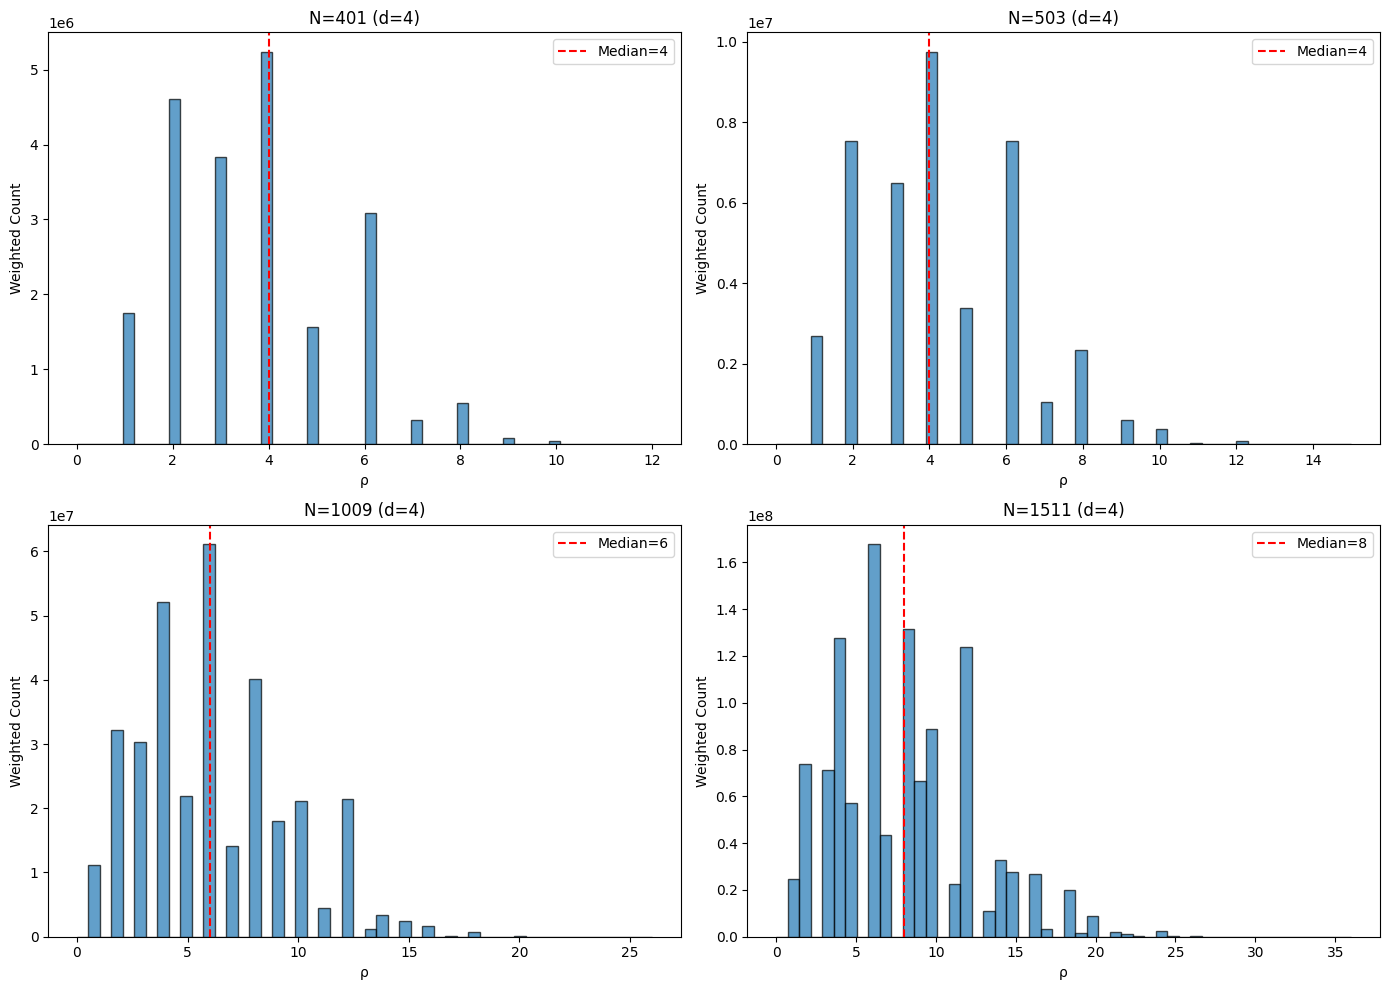

--- Stats for N=2003 ---
Total valid vectors: 1339342004
Min: 0, Median: 8, Max: 45


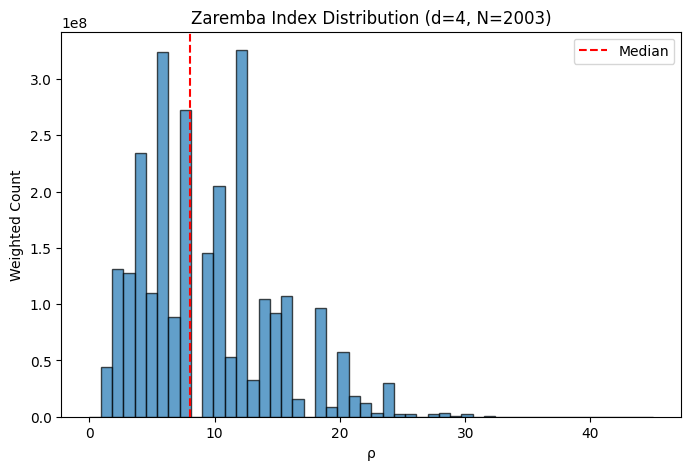

In [12]:
def analyze_and_plot_saved_data(N):
    # Load the precomputed data
    data = np.load(f"zaremba_4d_N{N}.npz")
    rhos = data['rhos']
    weights = data['weights']
    
    # Calculate weighted statistics instantly
    sorted_idx = np.argsort(rhos)
    rho_sorted = rhos[sorted_idx]
    w_sorted = weights[sorted_idx]
    cum_w = np.cumsum(w_sorted)
    total_w = cum_w[-1]
    
    def weighted_quantile(q):
        idx = np.searchsorted(cum_w, q * total_w)
        idx = min(idx, len(rho_sorted) - 1)
        return rho_sorted[idx]
        
    print(f"--- Stats for N={N} ---")
    print(f"Total valid vectors: {len(rhos)}")
    print(f"Min: {rho_sorted[0]}, Median: {weighted_quantile(0.50)}, Max: {rho_sorted[-1]}")
    
    # Plotting
    plt.figure(figsize=(8, 5))
    plt.hist(rhos, bins=50, weights=weights, edgecolor='black', alpha=0.7)
    plt.axvline(weighted_quantile(0.50), color='red', linestyle='--', label='Median')
    plt.title(f"Zaremba Index Distribution (d=4, N={N})")
    plt.xlabel("ρ")
    plt.ylabel("Weighted Count")
    plt.legend()
    plt.show()
    
def plot_4_histograms(N_list):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for i, N in enumerate(N_list):
        ax = axes[i]
        data = np.load(f"zaremba_4d_N{N}.npz")
        rhos = data['rhos']
        weights = data['weights']

        sorted_idx = np.argsort(rhos)
        rho_sorted = rhos[sorted_idx]
        w_sorted = weights[sorted_idx]
        cum_w = np.cumsum(w_sorted)
        total_w = cum_w[-1]
        median_idx = np.searchsorted(cum_w, 0.5 * total_w)
        median_idx = min(median_idx, len(rho_sorted) - 1)
        median_val = rho_sorted[median_idx]

        ax.hist(rhos, bins=50, weights=weights, edgecolor='black', alpha=0.7)
        ax.axvline(median_val, color='red', linestyle='--', label=f'Median={median_val}')
        ax.set_title(f"N={N} (d=4)")
        ax.set_xlabel("ρ")
        ax.set_ylabel("Weighted Count")
        ax.legend()

    plt.tight_layout()
    plt.show()

plot_4_histograms([401, 503, 1009, 1511])
analyze_and_plot_saved_data(2003)


### 5 Dimension

Now if we want to go into 5D it becomes even harder as even our previous changes would not suffice. In this case we would have to write machine code in C. <br>

Improvements:


- **Memory**: Uses O(1) RAM by streaming results directly to disk, eliminating the massive array memory crashes inherent to Python.

- **Compilation**: Uses Ahead-of-Time (AOT) compilation directly to optimized machine code, avoiding Numba's runtime (JIT) translation overhead.

- **Threading**: Uses OpenMP for direct, OS-level multithreading, bypassing Python's Global Interpreter Lock (GIL) and thread manager entirely.

<br>

The code is saved + documented in [fast_comp_C.c](./fast_comp_C.c) 
The compiled version is saved in [fast_comp_C](./fast_comp_C)

How to Run:
```python
import subprocess

# This executes the command: ./fast_comp_C <N>
# (If you are on Windows, change "./fast_comp_C" to "fast_comp_C.exe")
result = subprocess.run(["./fast_comp_C", str(N)], capture_output=True, text=True)

 # Print the output from the C program so you can see the progress
print(result.stdout)
        
# Check if the C program crashed or threw an error
if result.returncode != 0:
    print(f"ERROR running N={N}:")
    print(result.stderr)
    break
            
print(f"N={N} completed\n")
```

This will save the results in a csv file.

Now lets run it for N = [101, 151, 199, 251]

In [15]:
def generate_5d_csvs(n_values):
    print(f"Starting automated 5D runs for {len(n_values)} values...\n")
    
    for N in n_values:
        print(f"--- Running C Engine for N = {N} ---")
        t0 = time.time()
        result = subprocess.run(["./fast_comp_C", str(N)], capture_output=True, text=True)
    
        print(result.stdout)
        
        # Check if the C program crashed or threw an error
        if result.returncode != 0:
            print(f"ERROR running N={N}:")
            print(result.stderr)
            break
            
        elapsed = time.time() - t0
        print(f"✓ N={N} completed in {elapsed:.1f}s\n")

# Just list all the N values you want to process
target_N_values = [101, 151, 199, 251]

generate_5d_csvs(target_N_values)

Starting automated 5D runs for 4 values...

--- Running C Engine for N = 101 ---
Starting 5D Calculation for N = 101...
Finished! Processed 4421275 valid vectors.
Time elapsed: 3.81 seconds.
Results saved to zaremba_5d_N101.csv

✓ N=101 completed in 4.0s

--- Running C Engine for N = 151 ---
Starting 5D Calculation for N = 151...
Finished! Processed 21947850 valid vectors.
Time elapsed: 15.58 seconds.
Results saved to zaremba_5d_N151.csv

✓ N=151 completed in 15.6s

--- Running C Engine for N = 199 ---
Starting 5D Calculation for N = 199...
Finished! Processed 65998350 valid vectors.
Time elapsed: 43.86 seconds.
Results saved to zaremba_5d_N199.csv

✓ N=199 completed in 43.9s

--- Running C Engine for N = 251 ---
Starting 5D Calculation for N = 251...
Finished! Processed 166695375 valid vectors.
Time elapsed: 107.52 seconds.
Results saved to zaremba_5d_N251.csv

✓ N=251 completed in 107.5s



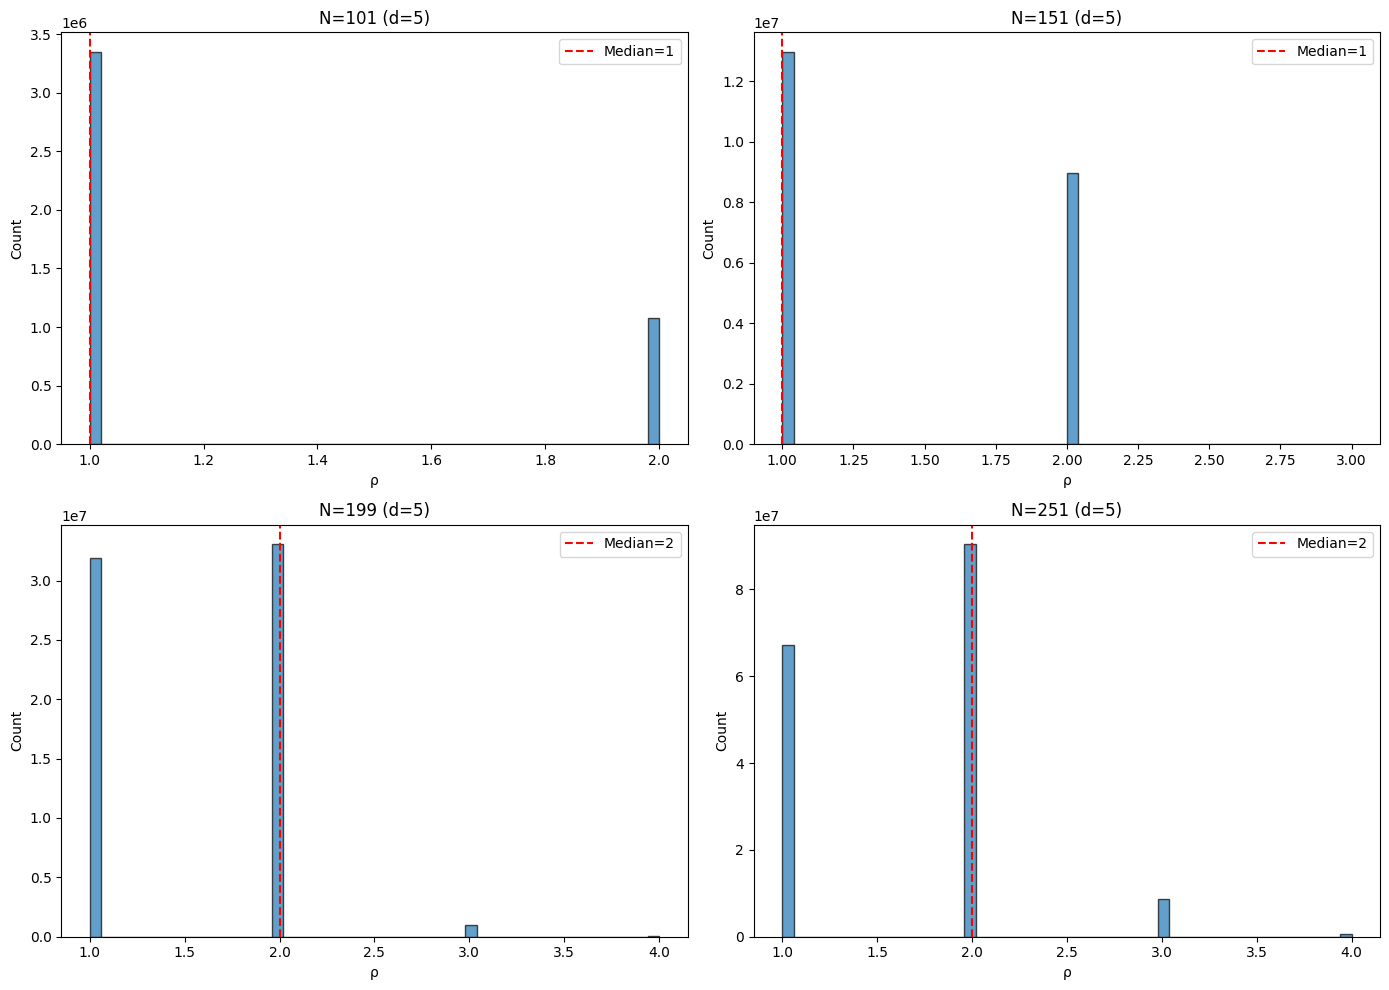

In [17]:
def plot_4_histograms_5d(N_list):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for i, N in enumerate(N_list):
        ax = axes[i]
        df = pd.read_csv(f"zaremba_5d_N{N}.csv")
        rhos = df['rho'].values

        median_val = int(np.median(rhos))

        ax.hist(rhos, bins=50, edgecolor='black', alpha=0.7)
        ax.axvline(median_val, color='red', linestyle='--', label=f'Median={median_val}')
        ax.set_title(f"N={N} (d=5)")
        ax.set_xlabel("ρ")
        ax.set_ylabel("Count")
        ax.legend()

    plt.tight_layout()
    plt.show()

plot_4_histograms_5d([101, 151, 199, 251])

These results look... intresting maybe we should try for larger N values?

I'll try for N = [401, 503, 1009, 1511]

In [ ]:
target_N_values = [401, 503, 1009, 1511]

generate_5d_csvs(target_N_values)

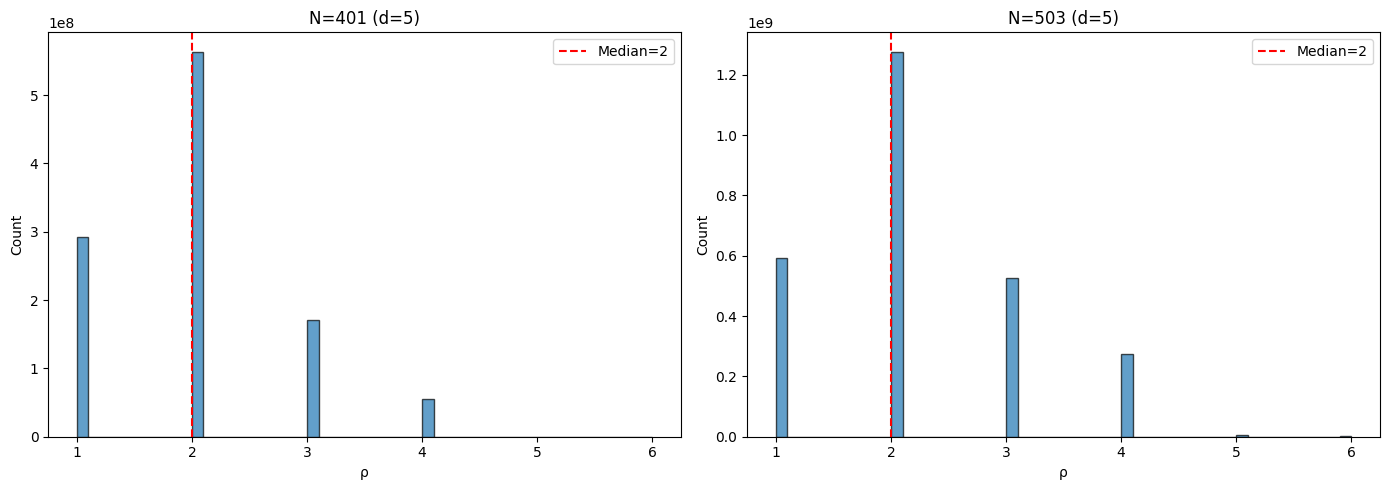

In [20]:
def plot_2_histograms_5d(N_list):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for i, N in enumerate(N_list):
        ax = axes[i]
        df = pd.read_csv(f"zaremba_5d_N{N}.csv")
        rhos = df['rho'].values

        median_val = int(np.median(rhos))

        ax.hist(rhos, bins=50, edgecolor='black', alpha=0.7)
        ax.axvline(median_val, color='red', linestyle='--', label=f'Median={median_val}')
        ax.set_title(f"N={N} (d=5)")
        ax.set_xlabel("ρ")
        ax.set_ylabel("Count")
        ax.legend()

    plt.tight_layout()
    plt.show()

plot_2_histograms_5d([401, 503])